# Neural Network Basics

```{contents}
:local:
:depth: 2
```

:::{admonition} Learning Objectives
:class: tip

By the end of this chapter, you will be able to:
- Explain why linear and kernel methods fall short for some problems and motivate the
  need for neural networks.
- Describe the computation performed by a single neuron (weighted sum + activation)
  and implement it from scratch.
- Compare step, sigmoid, and ReLU activation functions and explain why nonlinearity
  is essential for learning complex functions.
- Describe the architecture of a multi-layer perceptron (MLP) and explain the
  universal approximation theorem conceptually.
- Derive the chain rule for a two-layer network and explain how backpropagation
  distributes credit across layers.
- Fit `sklearn.neural_network.MLPRegressor` to a regression task, visualize the
  training loss curve, and tune hidden-layer size to control overfitting.
:::

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

plt.style.use('../settings/plot_style.mplstyle')

clrs = np.array(['#003057', '#EAAA00', '#4B8B9B', '#B3A369', '#377117',
                 '#1879DB', '#8E8B76', '#F5D580', '#002233'])

## Motivation: Where Simpler Methods Fall Short

The methods we have studied so far follow a common pattern: transform the raw features
into a new space, then apply a linear model. Kernel methods (KRR, SVM) achieve
nonlinearity by computing pairwise similarities; polynomial and symbolic regression
achieve it by constructing explicit products and powers of input features.

Both approaches have fundamental limitations:

- **Kernel methods** scale quadratically or cubically in the number of training points.
  A 50,000-point dataset requires a 50,000 × 50,000 kernel matrix — impractical.
- **Polynomial/symbolic regression** requires explicit feature construction that grows
  combinatorially with input dimension and polynomial degree.
- Neither approach learns a **hierarchical representation**: a face recognition model
  should learn edges first, then corners, then parts, then faces — not a flat
  transformation of raw pixel values.

Neural networks address all three limitations. They learn **layered feature
representations** directly from data, with computational cost that scales linearly
in the number of training samples at inference time.

The classic motivating example is the **XOR function**: two inputs $x_1, x_2 \in \{0,1\}$,
output 1 if exactly one input is 1, else 0. No linear model can separate the two
classes because they are not linearly separable in the original 2-D space — but a
two-layer network can.

:::{exercise}
:label: ex-eda-nn-xor-check

Verify that no linear model can solve XOR.

1. Fit `LinearRegression` to `X_xor` and `y_xor` and round the predictions to
   0 or 1. Report the accuracy.
2. Fit `SVC(kernel='linear')` and `SVC(kernel='rbf')`. Report accuracy for both.
3. Explain in one sentence why the RBF kernel SVC can solve XOR while a linear model
   cannot.
:::

In [2]:
# XOR: linear model fails, MLP succeeds
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([0, 1, 1, 0])

linear_svm = SVC(kernel='linear').fit(X_xor, y_xor)
mlp = MLPClassifier(hidden_layer_sizes=(4,), activation='relu', max_iter=5000,
                    random_state=0).fit(X_xor, y_xor)

print(f'Linear SVM accuracy:  {linear_svm.score(X_xor, y_xor):.2f}')
print(f'MLP accuracy:         {mlp.score(X_xor, y_xor):.2f}')

Linear SVM accuracy:  0.50
MLP accuracy:         1.00


---

## The Perceptron: A Single Neuron

### Computation

The fundamental unit of a neural network is the **neuron** (or perceptron). It:

1. Takes a vector of inputs $\mathbf{x} = [x_1, \ldots, x_n]$.
2. Computes a **weighted sum**: $z = \mathbf{w}^\top \mathbf{x} + b$.
3. Passes it through a nonlinear **activation function**: $a = \sigma(z)$.

In [3]:
def neuron(x, w, b, activation):
    z = np.dot(w, x) + b
    return activation(z)

# Step function (original perceptron)
step = lambda z: (z >= 0).astype(float)
# Sigmoid
sigmoid = lambda z: 1 / (1 + np.exp(-z))
# ReLU
relu = lambda z: np.maximum(0, z)

# Example: 2-input neuron with w = [1, -1], b = 0
w = np.array([1.0, -1.0])
b = 0.0
x_test = np.array([2.0, 1.0])
for name, fn in [('step', step), ('sigmoid', sigmoid), ('relu', relu)]:
    print(f'{name:8s}: z = {np.dot(w, x_test)+b:.2f},  a = {neuron(x_test, w, b, fn):.4f}')

step    : z = 1.00,  a = 1.0000
sigmoid : z = 1.00,  a = 0.7311
relu    : z = 1.00,  a = 1.0000


With a step activation, the neuron is a binary classifier: it fires ($a=1$) if the
weighted sum is positive. With sigmoid or ReLU, the output is a smooth function that
can represent graded responses.

### Visualizing the Linear Decision Boundary

A single neuron with a step or sigmoid activation places a **linear** decision boundary
in the input space — exactly the same as logistic regression:

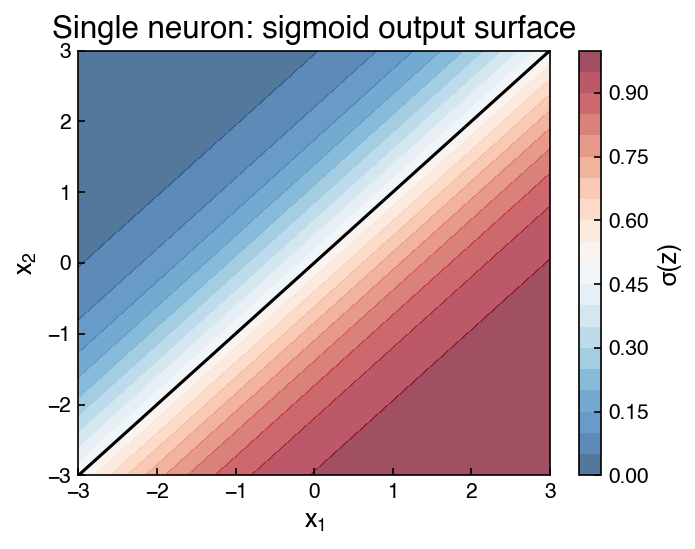

In [4]:
xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
Z = np.dot(np.column_stack([xx.ravel(), yy.ravel()]),
           np.array([1.0, -1.0])) + 0.0   # z = x1 - x2
Z_sig = sigmoid(Z).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(5, 4))
c = ax.contourf(xx, yy, Z_sig, levels=20, cmap='RdBu_r', alpha=0.7)
ax.contour(xx, yy, Z_sig, levels=[0.5], colors='k', linewidths=1.5)
fig.colorbar(c, ax=ax, label='σ(z)')
ax.set_title('Single neuron: sigmoid output surface')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
plt.tight_layout()

The straight black line is the decision boundary $z = 0$ (i.e., $x_1 - x_2 = 0$).
A single neuron can only separate data with a straight line — it cannot solve XOR.

:::{exercise}
:label: ex-eda-nn-neuron-impl

Implement and test a single neuron from scratch.

1. Using the `neuron` function defined above, create a neuron with weights
   `w = [2.0, -1.5]` and bias `b = 0.5`. Evaluate it on all four XOR inputs
   using the sigmoid activation. Report the four outputs.
2. Find weights and bias by hand (not by training) such that the neuron correctly
   classifies the AND function: output 1 only when both inputs are 1. Verify your
   solution by evaluating on all four inputs.
3. Is it possible to solve XOR with a single neuron and any choice of weights?
   Explain why or why not.
:::

---

## Activation Functions

### Why Nonlinearity Is Essential

If every neuron used a linear activation, stacking layers would still produce a linear
function: $W_2 (W_1 \mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 = (W_2 W_1)\mathbf{x} + \mathbf{b}'$
is just another linear transformation. Nonlinear activations are what allow multiple
layers to represent exponentially more complex functions.

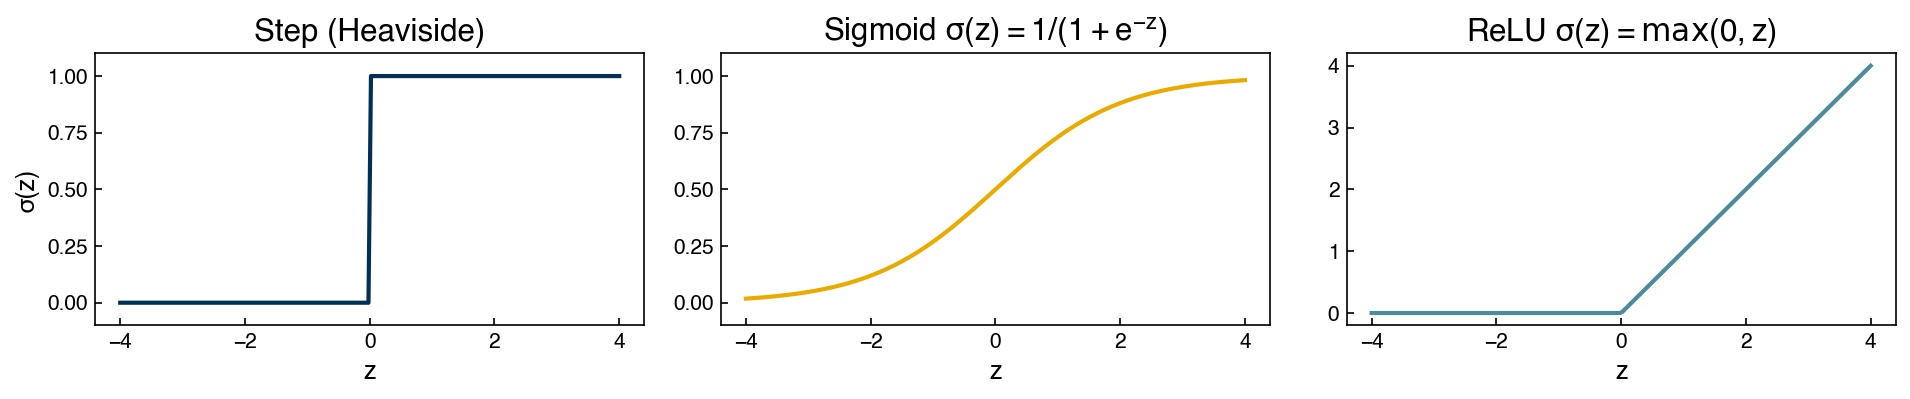

In [5]:
z = np.linspace(-4, 4, 200)

fig, axes = plt.subplots(1, 3, figsize=(13, 3))

# Step
axes[0].plot(z, step(z), color=clrs[0])
axes[0].set_title('Step (Heaviside)')
axes[0].set_ylim(-0.1, 1.1)
axes[0].set_xlabel('z')
axes[0].set_ylabel('σ(z)')

# Sigmoid
axes[1].plot(z, sigmoid(z), color=clrs[1])
axes[1].set_title('Sigmoid $σ(z) = 1/(1+e^{-z})$')
axes[1].set_ylim(-0.1, 1.1)
axes[1].set_xlabel('z')

# ReLU
axes[2].plot(z, relu(z), color=clrs[2])
axes[2].set_title('ReLU $σ(z) = \\max(0, z)$')
axes[2].set_xlabel('z')

plt.tight_layout()

| Activation | Range | Advantages | Disadvantages |
|---|---|---|---|
| **Step** | $\{0,1\}$ | Interpretable; original perceptron | Non-differentiable; no gradient |
| **Sigmoid** | $(0,1)$ | Smooth; natural probability output | Vanishing gradients for large $|z|$ |
| **Tanh** | $(-1,1)$ | Zero-centered | Vanishing gradients |
| **ReLU** | $[0,\infty)$ | Fast; no vanishing gradient for $z>0$ | "Dying ReLU" for $z < 0$ |
| **Leaky ReLU** | $(-\infty,\infty)$ | Fixes dying ReLU | One extra hyperparameter |

In practice, **ReLU** is the default for hidden layers in most modern networks.
Sigmoid and softmax are used in output layers for binary and multi-class classification
respectively.

:::{exercise}
:label: ex-eda-nn-activation-plot

Compare the gradient properties of activation functions.

1. Plot the sigmoid, tanh, and ReLU functions over $z \in [-4, 4]$ on the same axes.
2. Plot their derivatives (analytical or numerical) on a second set of axes.
3. For the sigmoid function, identify the range of $z$ where the gradient falls
   below 0.01. What fraction of the $[-4, 4]$ range does this represent?
4. Based on your plot, explain why ReLU is preferred over sigmoid for deep networks
   from a gradient flow perspective.
:::

---

## Multi-Layer Perceptrons

### Stacking Layers

A **multi-layer perceptron (MLP)** (also called a fully-connected or dense network)
stacks multiple layers of neurons. Each layer takes the activations of the previous
layer as input:

$$\mathbf{h}^{(1)} = \sigma(W^{(1)} \mathbf{x} + \mathbf{b}^{(1)})$$
$$\mathbf{h}^{(2)} = \sigma(W^{(2)} \mathbf{h}^{(1)} + \mathbf{b}^{(2)})$$
$$\hat{y} = W^{(3)} \mathbf{h}^{(2)} + b^{(3)}$$

(For regression, the output layer is typically linear; for classification, softmax.)

**The Universal Approximation Theorem** states that a single hidden layer with enough
neurons can approximate any continuous function on a compact domain — but this says
nothing about how many neurons are needed or how easily the model can be trained.
In practice, **depth** (more layers) is often more efficient than **width** (more
neurons per layer): each added layer can represent exponentially more functions for
the same number of parameters.

### Visualization: What Two-Layer XOR Looks Like

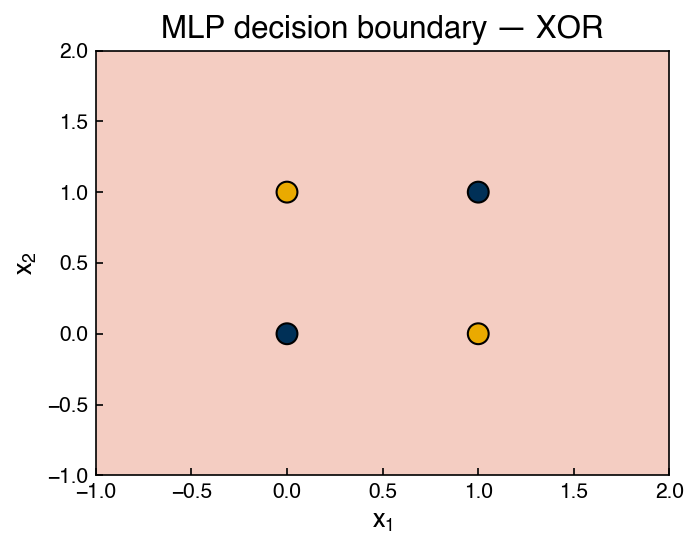

In [6]:
# Fit a two-layer MLP to XOR and visualize the decision surface
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import DecisionBoundaryDisplay

mlp_xor = MLPClassifier(hidden_layer_sizes=(4, 2), activation='relu',
                         max_iter=5000, random_state=42)
mlp_xor.fit(X_xor, y_xor)

fig, ax = plt.subplots(figsize=(5, 4))
DecisionBoundaryDisplay.from_estimator(mlp_xor, X_xor, response_method='predict',
                                        cmap='RdBu', alpha=0.4, ax=ax)
ax.scatter(X_xor[:, 0], X_xor[:, 1], c=[clrs[yi] for yi in y_xor],
           edgecolors='k', s=100, zorder=5)
ax.set_title('MLP decision boundary — XOR')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
plt.tight_layout()

The MLP finds a non-linear boundary that correctly separates the XOR pattern — something
no single neuron or linear model can achieve.

:::{exercise}
:label: ex-eda-nn-mlp-width

Explore the effect of hidden layer width on XOR and a regression task.

1. Fit `MLPClassifier` with `hidden_layer_sizes=(n,)` for $n \in \{1, 2, 4, 8\}$
   on the XOR data. For each, report accuracy and whether the model solves XOR
   perfectly. What is the minimum width needed?
2. Generate a 1-D regression dataset: `x = np.linspace(0, 2*np.pi, 100)`,
   `y = np.sin(x) + 0.1 * np.random.randn(100)`. Fit `MLPRegressor` with
   one hidden layer and widths `(4, 8, 16, 32, 64)`. Plot train and test $r^2$
   vs. width (use an 80/20 split). At what width does the model adequately fit
   the sine curve?
:::

---

## Training: Loss and Gradient Descent

### The Loss Surface

Training a neural network means finding weights $\{W^{(l)}, \mathbf{b}^{(l)}\}$ that
minimize a loss function. For regression, the standard choice is **mean squared error**:

$$\mathcal{L}(\theta) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i(\theta))^2$$

The loss is a function of all the weights — a surface in a very high-dimensional space.
For a deep network with millions of parameters, visualizing this surface is impossible,
but the key insight is that **gradient descent** can find a local minimum by repeatedly
moving in the direction of steepest descent:

$$\theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L}$$

where $\eta$ is the **learning rate** (step size). Too large and the optimizer
overshoots; too small and convergence is slow. **Mini-batch stochastic gradient descent
(SGD)** estimates the gradient from a random subset of data at each step, which is
faster and often finds better solutions than full-batch gradient descent.

:::{exercise}
:label: ex-eda-nn-lr-effect

Investigate the effect of learning rate on `MLPRegressor` training.

1. Using the sine regression data from the previous exercise (80/20 split,
   `hidden_layer_sizes=(32,)`, `random_state=0`), train `MLPRegressor` with
   learning rates `[1e-4, 1e-3, 1e-2, 0.1]` using `solver='sgd'` and
   `max_iter=200`.
2. Plot the training loss curve for each learning rate on the same axes.
3. Report the final train $r^2$ for each. Which learning rate converges fastest
   without diverging?
:::

---

## Training: Backpropagation

### The Chain Rule on a Two-Layer Network

The challenge of training deep networks is computing $\nabla_\theta \mathcal{L}$
efficiently — the gradient of the loss with respect to weights in the first layer
depends on how those weights affect the output through all subsequent layers.
**Backpropagation** solves this with the chain rule of calculus.

Consider a minimal two-layer network with scalar inputs and outputs:

$$z_1 = w_1 x + b_1, \quad h = \sigma(z_1)$$
$$z_2 = w_2 h + b_2, \quad \hat{y} = z_2$$
$$\mathcal{L} = (\hat{y} - y)^2$$

The gradient with respect to $w_1$ (the first-layer weight) is:

$$\frac{\partial \mathcal{L}}{\partial w_1} =
  \underbrace{\frac{\partial \mathcal{L}}{\partial \hat{y}}}_{\text{output layer error}}
  \cdot
  \underbrace{\frac{\partial \hat{y}}{\partial h}}_{\text{= }w_2}
  \cdot
  \underbrace{\frac{\partial h}{\partial z_1}}_{\text{= }\sigma'(z_1)}
  \cdot
  \underbrace{\frac{\partial z_1}{\partial w_1}}_{\text{= }x}$$

In words: the output error is multiplied by the second-layer weight (how much the
output depends on $h$), then by the activation derivative (how much $h$ changes when
$z_1$ changes), then by the input $x$ (how much $z_1$ changes when $w_1$ changes).

In [7]:
# Manual forward + backward pass for a one-hidden-neuron network
def forward(x, w1, b1, w2, b2):
    z1 = w1 * x + b1
    h  = sigmoid(z1)
    z2 = w2 * h + b2
    yhat = z2
    return yhat, h, z1

def backward(x, y, yhat, h, z1, w2):
    dL_dyhat = 2 * (yhat - y)           # ∂L/∂ŷ
    dyhat_dh = w2                        # ∂ŷ/∂h
    dh_dz1   = sigmoid(z1) * (1 - sigmoid(z1))   # σ' = σ(1-σ)
    dz1_dw1  = x                         # ∂z1/∂w1

    dL_dw2 = dL_dyhat * h
    dL_dw1 = dL_dyhat * dyhat_dh * dh_dz1 * dz1_dw1
    return dL_dw1, dL_dw2

# Example: one data point
x, y_true = 2.0, 1.5
w1, b1, w2, b2 = 0.5, 0.0, -0.3, 0.0

yhat, h, z1 = forward(x, w1, b1, w2, b2)
dw1, dw2 = backward(x, y_true, yhat, h, z1, w2)

print(f'Forward:  z1={z1:.4f},  h={h:.4f},  ŷ={yhat:.4f}')
print(f'Loss:     {(yhat - y_true)**2:.4f}')
print(f'∂L/∂w1 = {dw1:.6f}')
print(f'∂L/∂w2 = {dw2:.6f}')

Forward:  z1=1.0000,  h=0.7311,  ŷ=-0.2193
Loss:     2.9561
∂L/∂w1 = 0.405646
∂L/∂w2 = -2.513844


This manual calculation is exactly what PyTorch's `autograd` engine performs
automatically for any computational graph, regardless of depth or architecture —
the key innovation that makes deep learning tractable.

:::{exercise}
:label: ex-eda-nn-backprop

Verify the manual backpropagation calculation numerically.

1. Using the `forward` and `backward` functions above with `x=2.0`, `y_true=1.5`,
   `w1=0.5`, `b1=0.0`, `w2=-0.3`, `b2=0.0`, compute the analytical gradients
   `dL_dw1` and `dL_dw2`.
2. Compute the same gradients numerically using finite differences:
   $\partial L / \partial w_1 \approx [L(w_1 + h) - L(w_1 - h)] / (2h)$ with $h = 10^{-5}$.
3. Report the absolute difference between the analytical and numerical gradients.
   Are they in agreement to at least 6 decimal places?
:::

---

## Demonstration: `MLPRegressor` on the Dow Dataset

### Fitting and Training Loss

In [8]:
from sklearn.neural_network import MLPRegressor

# Load and prepare Dow data
df = pd.read_excel('data/impurity_dataset-training.xlsx')

def is_real_and_finite(x):
    try:
        val = float(x)
        return np.isfinite(val)
    except (TypeError, ValueError):
        return False

nondate = df.columns[1:]
numeric_map = df[nondate].apply(lambda col: col.map(is_real_and_finite))
real_rows = numeric_map.all(axis=1).values

X_dow = df[nondate].values[real_rows, :-5].astype(float)
y_dow = df[nondate].values[real_rows, -3].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X_dow, y_dow, test_size=0.2, random_state=0)

# Standardize
scaler = StandardScaler()
X_tr = scaler.fit_transform(X_train)
X_te = scaler.transform(X_test)

In [9]:
mlp_reg = MLPRegressor(
    hidden_layer_sizes=(64,),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=0,
    verbose=False,
)
mlp_reg.fit(X_tr, y_train)

print(f'Train r²: {mlp_reg.score(X_tr, y_train):.3f}')
print(f'Test  r²: {mlp_reg.score(X_te, y_test):.3f}')
print(f'Stopped at iteration: {mlp_reg.n_iter_}')

Train r²: 0.914
Test  r²: 0.902
Stopped at iteration: 161


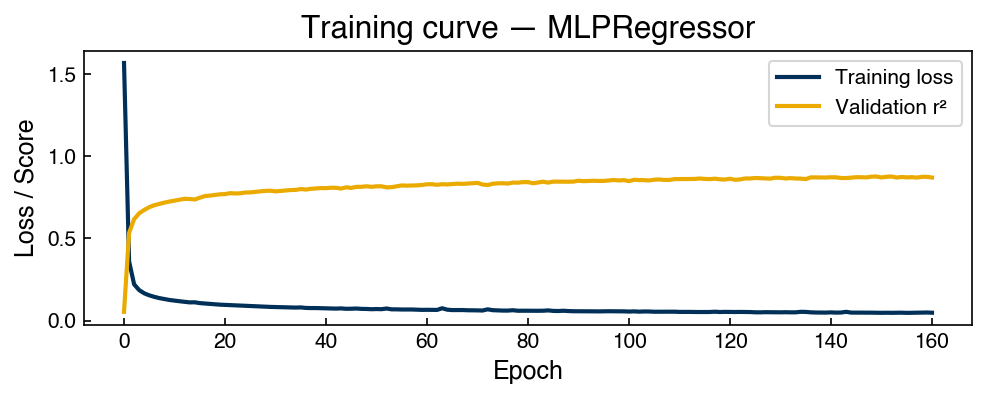

In [10]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(mlp_reg.loss_curve_, label='Training loss')
ax.plot(mlp_reg.validation_scores_, label='Validation r²')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss / Score')
ax.set_title('Training curve — MLPRegressor')
ax.legend()
plt.tight_layout()

### Effect of Hidden Layer Size

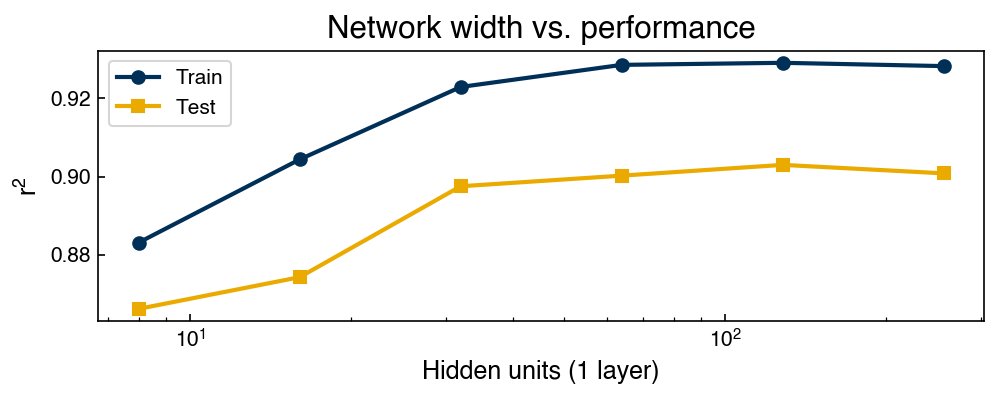

In [11]:
sizes = [8, 16, 32, 64, 128, 256]
train_scores, test_scores = [], []

for n in sizes:
    m = MLPRegressor(hidden_layer_sizes=(n,), activation='relu', solver='adam',
                     max_iter=500, random_state=0)
    m.fit(X_tr, y_train)
    train_scores.append(m.score(X_tr, y_train))
    test_scores.append(m.score(X_te, y_test))

fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogx(sizes, train_scores, 'o-', label='Train')
ax.semilogx(sizes, test_scores,  's-', label='Test')
ax.set_xlabel('Hidden units (1 layer)')
ax.set_ylabel('$r^2$')
ax.set_title('Network width vs. performance')
ax.legend()
plt.tight_layout()

As the hidden layer grows, training $r^2$ increases monotonically (the model has more
capacity), but test $r^2$ peaks and may decrease — the signature of overfitting.
Early stopping (`early_stopping=True`) helps, but is not a substitute for choosing a
network architecture appropriate to the dataset size.

:::{exercise}
:label: ex-eda-nn-mlp

Using the Dow dataset with `X_tr`, `X_te`, `y_train`, `y_test` from above, explore
the effect of network depth.

1. Train `MLPRegressor` with one hidden layer of 64 units and then with two hidden
   layers of sizes `(64, 32)`. Use `early_stopping=True` and `random_state=0`.
   Report train and test $r^2$ for both.
2. Plot the training loss curve for each configuration on the same axes. Which
   converges faster?
3. Change the activation from `'relu'` to `'tanh'` for the two-layer network. Does
   it affect the test $r^2$?
4. From the bias-variance perspective, what does a high train $r^2$ but low test $r^2$
   tell you about the model?
:::

---

## Hyperparameter Guide

The table below summarizes the most important hyperparameters and how to tune them:

| Hyperparameter | What it controls | Practical guidance |
|---|---|---|
| **Hidden layer sizes** (depth × width) | Model capacity | Start with 1–2 layers, 32–128 units; increase only if underfitting |
| **Activation** | Nonlinearity type | Use `'relu'` by default; `'tanh'` for smooth outputs |
| **Learning rate** | Step size in SGD | Adam with default lr (0.001) works well; decrease if loss oscillates |
| **Batch size** | Gradient noise level | Larger batches → smoother gradients; smaller → more regularization |
| **Early stopping** | Overfitting control | Always enable for small datasets; monitor validation loss |
| **L2 regularization** (`alpha`) | Weight magnitude penalty | Increase if test r² << train r² |

:::{exercise}
:label: ex-eda-nn-l2-reg

Explore the effect of L2 regularization on the Dow MLPRegressor.

1. Using `X_tr`, `X_te`, `y_train`, `y_test` from above, train `MLPRegressor` with
   `hidden_layer_sizes=(128,)`, `solver='adam'`, `max_iter=500`, `random_state=0`,
   and L2 penalty `alpha` swept over `[1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1.0]`.
2. For each `alpha`, record train $r^2$ and test $r^2$.
3. Plot train and test $r^2$ vs. `log10(alpha)`. Identify the `alpha` that maximizes
   test $r^2$ and note how the gap between train and test $r^2$ changes.
:::

---

## Summary

- Neural networks learn **layered feature representations**: each layer transforms
  the previous layer's activations, allowing the network to represent arbitrarily
  complex functions.

- A single neuron computes $a = \sigma(\mathbf{w}^\top \mathbf{x} + b)$. Without a
  nonlinear activation $\sigma$, stacking layers is equivalent to a single linear model.

- Common activations: **step** (non-differentiable, historical), **sigmoid** (smooth,
  vanishing gradient for large $|z|$), **ReLU** (fast, no vanishing gradient for
  $z > 0$, default for hidden layers).

- **Backpropagation** applies the chain rule to propagate the gradient from the output
  back through each layer, enabling efficient computation of $\nabla_\theta \mathcal{L}$
  for any depth.

- `sklearn.neural_network.MLPRegressor` provides a practical interface for regression
  with MLPs. Training loss curves and width/depth sweeps are essential diagnostics for
  understanding capacity and overfitting.

## Additional Reading

- Goodfellow, I., Bengio, Y. & Courville, A. (2016), *Deep Learning* — the standard
  reference, free at [deeplearningbook.org](https://www.deeplearningbook.org/)
- Nielsen, M. A. (2015), *Neural Networks and Deep Learning* — free online book
  with excellent visual intuitions: [neuralnetworksanddeeplearning.com](http://neuralnetworksanddeeplearning.com/)
- scikit-learn User Guide:
  [MLPRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html),
  [Neural network models](https://scikit-learn.org/stable/modules/neural_networks_supervised.html)